In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import os

#show all columns
pd.set_option("display.max_columns", 100)

#get the data and show beginning to conceptualize
data = pd.read_csv("credit_cards_2025-post.csv")
data.head(20)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,17270,130000,2,2,1,34,0,0,0,0,0,0,99891,101032,104705,105478,107725,109994,3700,5300,4000,4000,4000,6100,0
1,22364,290000,2,1,2,27,-1,-1,0,0,0,0,168,569,1401,1503,834,931,569,1000,1000,200,265,500,0
2,23880,360000,1,1,2,27,-2,-2,-2,-2,-2,-2,2807,894,5939,1390,-5,-5,898,5970,1396,0,0,0,0
3,9074,110000,2,1,2,35,-1,2,-1,0,0,-1,549,179,1166,790,806,1729,0,1166,0,446,1729,0,0
4,25083,260000,1,3,1,48,0,0,0,0,0,0,154927,158848,160654,155059,141570,134143,8000,6000,7100,5300,5000,5000,0
5,5239,380000,1,1,1,32,0,0,0,0,0,0,53369,73954,35199,31136,28839,14584,30307,5044,5036,5081,2022,2026,0
6,17809,10000,1,2,2,24,3,2,2,3,3,3,1050,1050,1050,1050,1050,1050,0,0,0,0,0,0,1
7,10159,500000,2,2,2,36,-2,-2,-2,-2,-2,-2,11168,9287,9963,17145,7645,16079,9287,9963,17223,7645,16079,11288,0
8,7681,220000,1,2,1,49,0,0,0,0,0,0,153880,143020,117567,153069,153045,144529,6300,4500,37486,6000,5200,5002,0
9,1636,80000,1,3,2,29,0,0,0,0,0,0,46638,47680,48395,49356,50560,51431,2091,1806,1767,2000,1767,1740,0


In [52]:
# Find unique values in data with limited valid values
# Catch invalid values
print("SEX:", data["SEX"].unique())
print("EDUCATION:", data["EDUCATION"].unique())
print("MARRIAGE:", data["MARRIAGE"].unique())
print("DEFAULT:", data["DEFAULT"].unique())

# Show range data to see if anything odd happens
print("AGE range:", data["AGE"].min(), "to", data["AGE"].max())
print("ID range:", data["ID"].min(), "to", data["ID"].max())
print("LIMIT_BAL range:", data["LIMIT_BAL"].min(), "to", data["LIMIT_BAL"].max())

#BILL_AMT & PAY_AMT have multiple columns, find range for each column c
billc = [c for c in data.columns if "BILL_AMT" in c]
for i in billc:
    print(f"{i} range:", data[i].min(), "to", data[i].max())

payc = [c for c in data.columns if "PAY_AMT" in c]
for i in payc:
    print(f"{i} range:", data[i].min(), "to", data[i].max())

SEX: [2 1]
EDUCATION: [2 1 3 5 4 6 0]
MARRIAGE: [1 2 3 0]
DEFAULT: [0 1]
AGE range: 21 to 75
ID range: 1 to 30000
LIMIT_BAL range: 10000 to 1000000
BILL_AMT1 range: -154973 to 964511
BILL_AMT2 range: -69777 to 983931
BILL_AMT3 range: -157264 to 1664089
BILL_AMT4 range: -170000 to 891586
BILL_AMT5 range: -81334 to 927171
BILL_AMT6 range: -339603 to 961664
PAY_AMT1 range: 0 to 873552
PAY_AMT2 range: 0 to 1684259
PAY_AMT3 range: 0 to 896040
PAY_AMT4 range: 0 to 621000
PAY_AMT5 range: 0 to 426529
PAY_AMT6 range: 0 to 528666


In [53]:
# Find any missing or N/A values 
missing_vals = data.isna()
print(missing_vals)


          ID  LIMIT_BAL    SEX  EDUCATION  MARRIAGE    AGE  PAY_1  PAY_2  \
0      False      False  False      False     False  False  False  False   
1      False      False  False      False     False  False  False  False   
2      False      False  False      False     False  False  False  False   
3      False      False  False      False     False  False  False  False   
4      False      False  False      False     False  False  False  False   
...      ...        ...    ...        ...       ...    ...    ...    ...   
23995  False      False  False      False     False  False  False  False   
23996  False      False  False      False     False  False  False  False   
23997  False      False  False      False     False  False  False  False   
23998  False      False  False      False     False  False  False  False   
23999  False      False  False      False     False  False  False  False   

       PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  \
0     

Frequency: 
DEFAULT
0    18633
1     5367
Name: count, dtype: int64

Mode: 
0


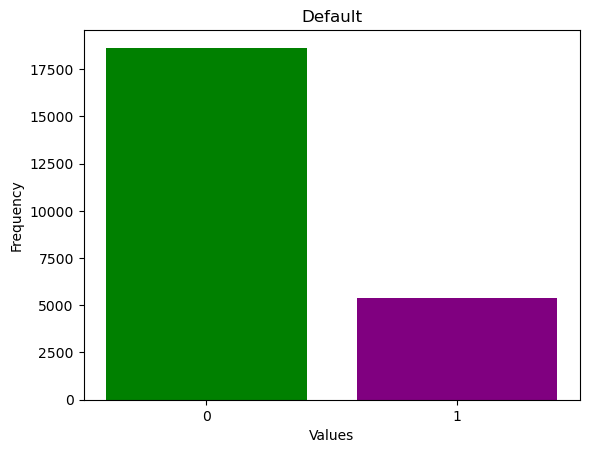

In [54]:
#Default column
#find mode and frequency and print
frequency = data["DEFAULT"].value_counts().sort_index()
print("Frequency: ")
print(frequency)
mode = data["DEFAULT"].mode()[0]
print("\nMode: ")
print(mode)

import matplotlib.pyplot as plt

#Create plot with frequency of 1 vs 0 for Default
plt.bar(frequency.index, frequency.values, color=["green", "purple"])
plt.title("Default")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.xticks([0,1])
plt.show()

In [55]:
#Task 2

In [56]:
#Get summary statistics from BILL_AMT columns
pd.set_option('display.float_format', '{:.2f}'.format)
billc = [i for i in data.columns if "BILL_AMT" in i]
bill_vals = data[billc].describe()
print(bill_vals)


       BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
count   24000.00   24000.00   24000.00   24000.00   24000.00   24000.00
mean    51069.80   49050.72   46870.75   43104.47   40229.08   38779.37
std     73745.22   71162.25   69436.39   63907.82   60576.64   59440.28
min   -154973.00  -69777.00 -157264.00 -170000.00  -81334.00 -339603.00
25%      3490.00    2935.75    2634.50    2315.00    1726.25    1225.75
50%     21986.00   20897.00   19917.00   18937.50   18018.00   16933.50
75%     66822.75   63816.50   59873.50   54444.50   50171.50   49146.25
max    964511.00  983931.00 1664089.00  891586.00  927171.00  961664.00


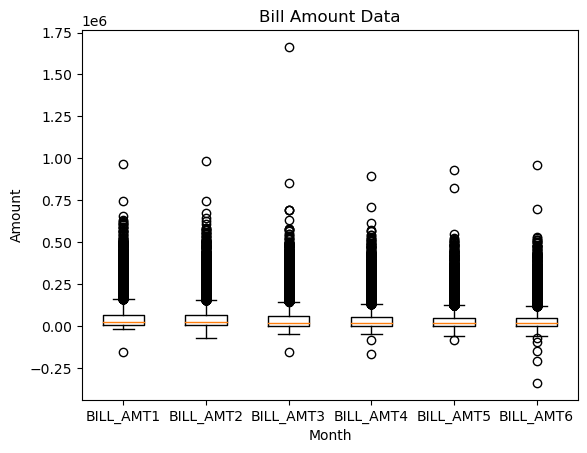

In [57]:
import matplotlib.pyplot as plt

#create box plots for BILL_AMT and display in graph
billc = [i for i in data.columns if "BILL_AMT" in i]
plt.boxplot([data[c] for c in billc], labels=billc)
plt.title("Bill Amount Data")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

In [58]:
#Task 3

In [75]:
import numpy as np
import pandas as pd
#Separate categorical data and numerical data

#copy data to preserve
data3 = data.copy()

#cat: sex, education, marriage, pay
cat = ["SEX", "EDUCATION", "MARRIAGE"] + [i for i in data3.columns if i.startswith("PAY_") and not i.startswith("PAY_AMT")]
#num: limit, age, bill_amt, pay_amt
num = ["LIMIT_BAL", "AGE"] +[i for i in data3.columns if i.startswith("BILL_AMT")] + [i for i in data3.columns if i.startswith("PAY_AMT")]

print("Categorical:", cat)
print("Numerical ({}):".format(len(num)), num[:8])

Categorical: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numerical (14): ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']


In [60]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import chi2, mutual_info_classif
#encode cat data for chi2 scores

#initiate encoder
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = enc.fit_transform(data3[cat])

#get DEFAULT values
y3 = data3["DEFAULT"].values

#get scores
chi2_scores, chi2_p = chi2(X_cat, y3)

#aggregate chi2 score by column for readability
agg = {}
start = 0
for c, vals in zip(cat, enc.categories_):
    k = len(vals)
    scores = chi2_scores[start:start+k]
    agg[c] = float(np.nanmax(scores)) if k else np.nan
    start += k

#Rank scores
chi2_rank = pd.DataFrame(
    sorted(agg.items(), key=lambda x: x[1], reverse=True),
    columns=["cat feature","chi2 score"]
)

print(chi2_rank)

  cat feature  chi2 score
0       PAY_1     2696.09
1       PAY_2     2085.12
2       PAY_3     1545.41
3       PAY_4     1359.28
4       PAY_5     1270.26
5       PAY_6     1085.46
6   EDUCATION       49.92
7         SEX       27.09
8    MARRIAGE        9.01


In [61]:
#Use mutual info scaler for num data

#initiate scaler
scaler = MinMaxScaler()
X_num = scaler.fit_transform(data3[num])

#get scores
scores = mutual_info_classif(X_num, y3, discrete_features=False, random_state=0)

#Rank scores
mi_rank = pd.DataFrame(
    sorted(zip(num, scores), key=lambda x: x[1], reverse=True),
    columns=["num feature", "mutual info"]
)

print(mi_rank)




   num feature  mutual info
0     PAY_AMT1         0.02
1     PAY_AMT3         0.02
2     PAY_AMT4         0.02
3     PAY_AMT2         0.02
4     PAY_AMT5         0.01
5    LIMIT_BAL         0.01
6    BILL_AMT2         0.01
7    BILL_AMT1         0.01
8     PAY_AMT6         0.01
9    BILL_AMT6         0.01
10   BILL_AMT5         0.01
11   BILL_AMT3         0.01
12   BILL_AMT4         0.00
13         AGE         0.00


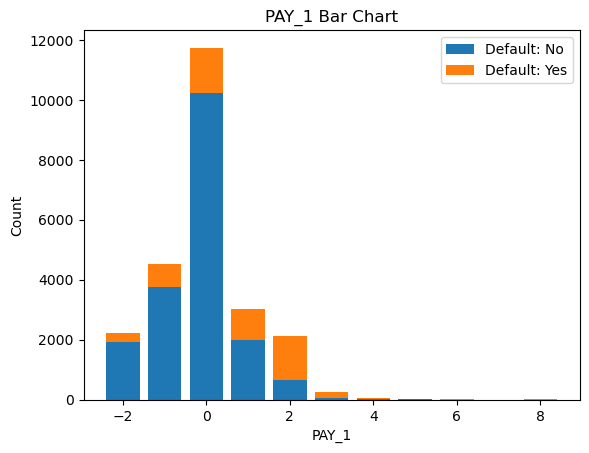

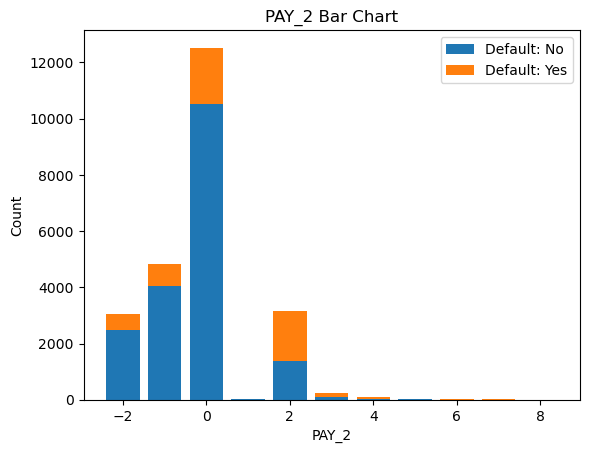

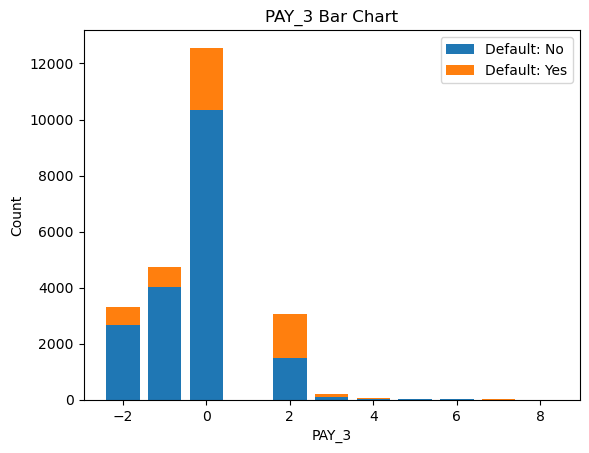

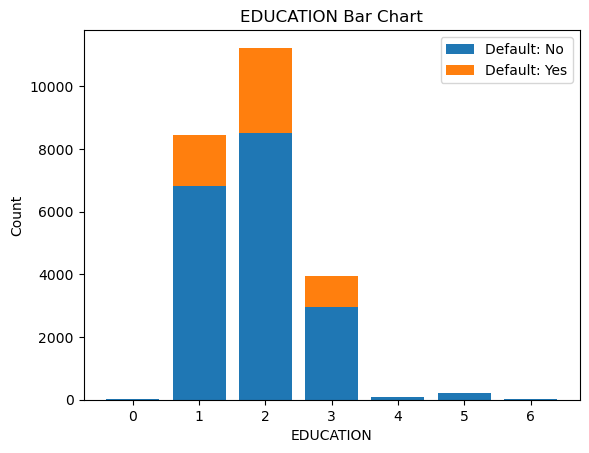

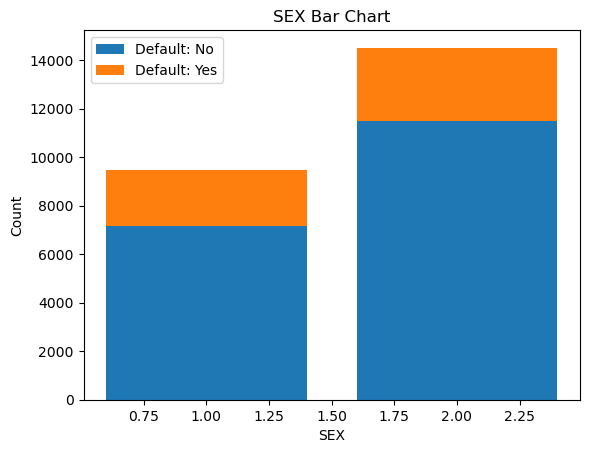

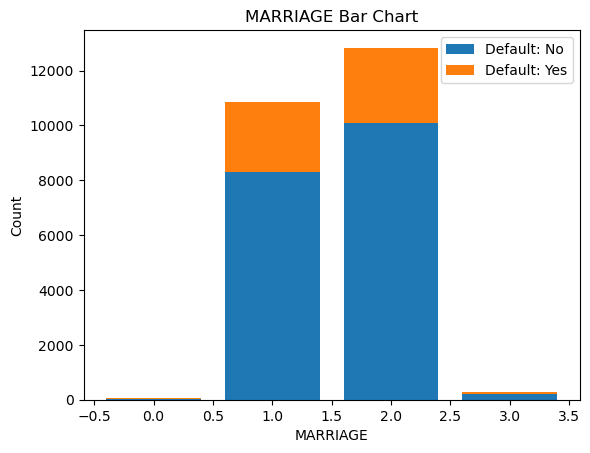

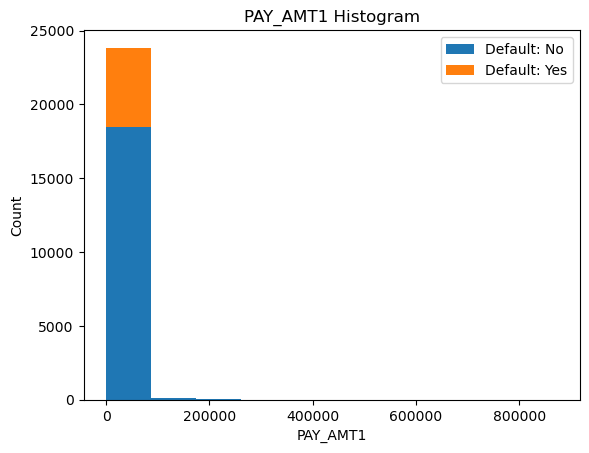

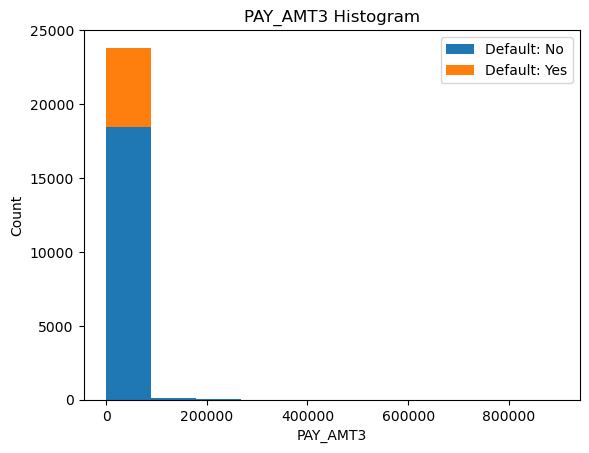

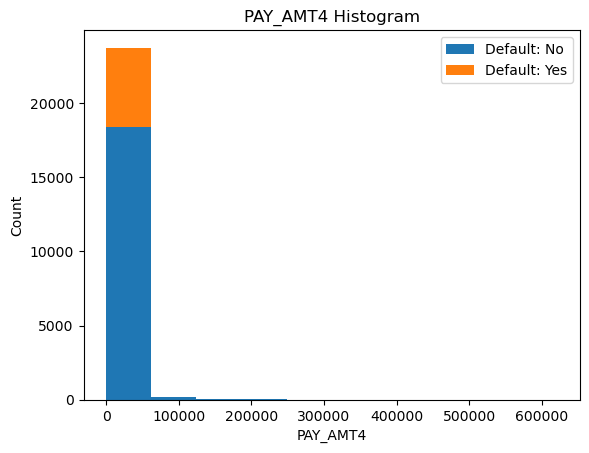

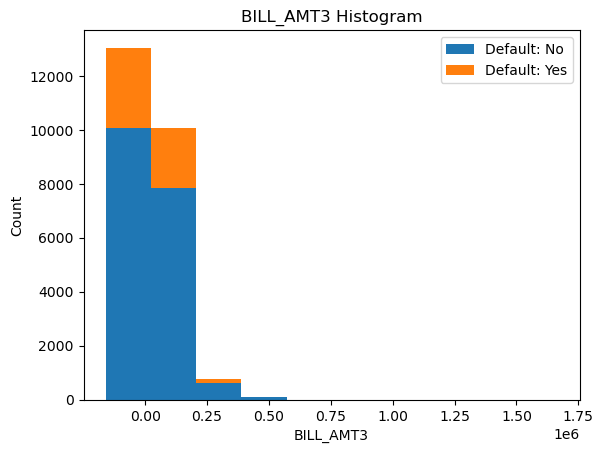

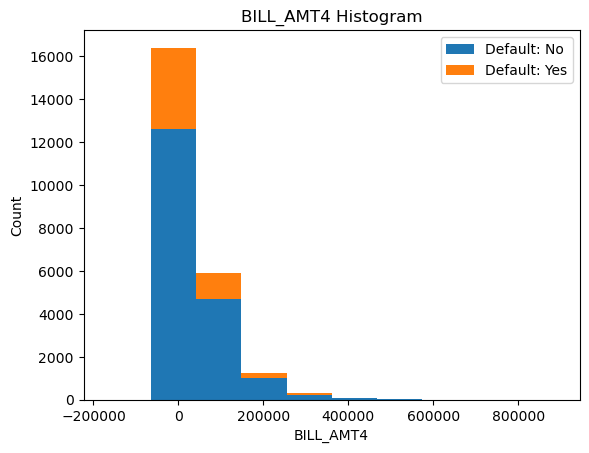

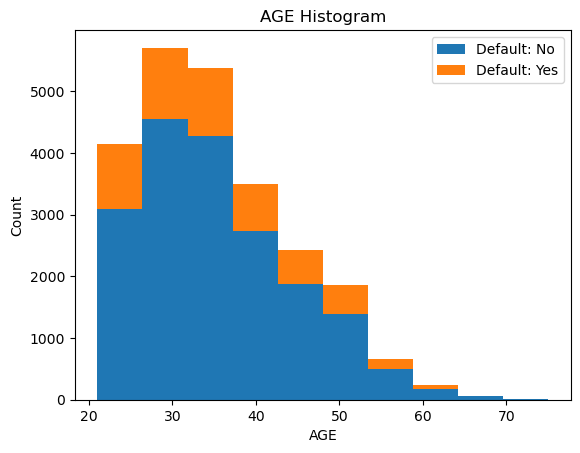

In [63]:
#plot top and bottom 3 for cat and num

#plot cat data with bar chart
#get val counts for DEFAULT 0,1, combine and plot
def plot_cat(c):
    ct0 = data3[data3["DEFAULT"]==0][c].value_counts().sort_index()
    ct1 = data3[data3["DEFAULT"]==1][c].value_counts().sort_index()
    xs = sorted(set(ct0.index).union(set(ct1.index)))
    y0 = [ct0.get(x, 0) for x in xs]
    y1 = [ct1.get(x, 0) for x in xs]

    plt.bar(xs, y0, label="Default: No")
    plt.bar(xs, y1, bottom=y0, label="Default: Yes")

    plt.title(f"{c} Bar Chart")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

#plot num data with histogram
#get num val counts for DEFAULT 0,1, combine and plot
def plot_num(c):
    v0 = data3[data3["DEFAULT"]==0][c].dropna().values
    v1 = data3[data3["DEFAULT"]==1][c].dropna().values
    both = np.concatenate([v0, v1])
    vmin = both.min()
    vmax = both.max()
    bins = np.linspace(vmin, vmax, 11) 

    plt.hist([v0, v1], bins=bins, stacked=True, label=["Default: No","Default: Yes"])
    plt.title(f"{c} Histogram")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

#get top 3, bottom 3 cat
t3cat = chi2_rank["cat feature"].head(3).tolist()
b3cat = chi2_rank["cat feature"].tail(3).tolist()
#get top 3, bottom 3 num
t3num    = mi_rank["num feature"].head(3).tolist()
b3num = mi_rank["num feature"].tail(3).tolist()

#iterate through each and plot
for c in t3cat:
    plot_cat(c)

for c in b3cat:
    plot_cat(c)

for c in t3num:
    plot_num(c)

for c in b3num:
    plot_num(c)



In [ ]:
#Task 4

In [64]:
import numpy as np
import pandas as pd

#copy data to preserve
data4 = data.copy()

#create new column for average pay time, mean pay_1 - pay_6
data4["AVG_PAY_TIME"] = data4[["PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].mean(axis=1)

#Move default to end
c = data4.columns.tolist()
c.remove("DEFAULT")
data4 = data4[["ID"] + [i for i in c if i not in ["ID", "DEFAULT"]] + ["DEFAULT"]]



In [65]:
from sklearn.preprocessing import MinMaxScaler

#get num columns to normalize
numc = ["LIMIT_BAL","AGE"] + [i for i in data4.columns if i.startswith("BILL_AMT")] + [i for i in data4.columns if i.startswith("PAY_AMT")] + ["AVG_PAY_TIME"]


#initialize scaler, copy, normalize
scaler = MinMaxScaler()
data4_norm = data4.copy()
data4_norm[numc] = scaler.fit_transform(data4[numc])

#show original vs normalized
print("\n Original vs Normalized:")
for c in numc:
    orig_min, orig_max = data4[c].min(), data4[c].max()
    norm_min, norm_max = data4_norm[c].min(), data4_norm[c].max()
    print(f"{c:12}  original: [{orig_min:9.2f}, {orig_max:9.2f}]   normalized: [{norm_min:.2f}, {norm_max:.2f}]")




 Original vs Normalized:
LIMIT_BAL     original: [ 10000.00, 1000000.00]   normalized: [0.00, 1.00]
AGE           original: [    21.00,     75.00]   normalized: [0.00, 1.00]
BILL_AMT1     original: [-154973.00, 964511.00]   normalized: [0.00, 1.00]
BILL_AMT2     original: [-69777.00, 983931.00]   normalized: [0.00, 1.00]
BILL_AMT3     original: [-157264.00, 1664089.00]   normalized: [0.00, 1.00]
BILL_AMT4     original: [-170000.00, 891586.00]   normalized: [0.00, 1.00]
BILL_AMT5     original: [-81334.00, 927171.00]   normalized: [0.00, 1.00]
BILL_AMT6     original: [-339603.00, 961664.00]   normalized: [0.00, 1.00]
PAY_AMT1      original: [     0.00, 873552.00]   normalized: [0.00, 1.00]
PAY_AMT2      original: [     0.00, 1684259.00]   normalized: [0.00, 1.00]
PAY_AMT3      original: [     0.00, 896040.00]   normalized: [0.00, 1.00]
PAY_AMT4      original: [     0.00, 621000.00]   normalized: [0.00, 1.00]
PAY_AMT5      original: [     0.00, 426529.00]   normalized: [0.00, 1.00]
PAY_A

In [66]:
#get cat data to encode (one-hot), count 1's
catc = ["SEX","EDUCATION","MARRIAGE"] + [c for c in data4.columns if c.startswith("PAY_") and not c.startswith("PAY_AMT")]

#perform encoding
data4_encoded = pd.get_dummies(data4, columns=catc, prefix=catc)

#count 1's
ohcounts = (data4_encoded[data4_encoded.columns.difference(data4.columns)] == 1).sum()

#show feature counts
print("\nOne-hot feature counts:")
for feature, count in ohcounts.items():
    print(f"{feature}: {count}")

print("\nTotal new one-hot encoded features created:", len(ohcounts))


One-hot feature counts:
EDUCATION_0: 11
EDUCATION_1: 8450
EDUCATION_2: 11227
EDUCATION_3: 3958
EDUCATION_4: 102
EDUCATION_5: 217
EDUCATION_6: 35
MARRIAGE_0: 45
MARRIAGE_1: 10856
MARRIAGE_2: 12832
MARRIAGE_3: 267
PAY_1_-1: 4513
PAY_1_-2: 2224
PAY_1_0: 11737
PAY_1_1: 3033
PAY_1_2: 2126
PAY_1_3: 254
PAY_1_4: 58
PAY_1_5: 23
PAY_1_6: 8
PAY_1_7: 7
PAY_1_8: 17
PAY_2_-1: 4831
PAY_2_-2: 3067
PAY_2_0: 12525
PAY_2_1: 26
PAY_2_2: 3162
PAY_2_3: 254
PAY_2_4: 85
PAY_2_5: 21
PAY_2_6: 10
PAY_2_7: 18
PAY_2_8: 1
PAY_3_-1: 4748
PAY_3_-2: 3292
PAY_3_0: 12563
PAY_3_1: 3
PAY_3_2: 3067
PAY_3_3: 204
PAY_3_4: 61
PAY_3_5: 17
PAY_3_6: 20
PAY_3_7: 22
PAY_3_8: 3
PAY_4_-1: 4517
PAY_4_-2: 3492
PAY_4_0: 13136
PAY_4_1: 2
PAY_4_2: 2574
PAY_4_3: 142
PAY_4_4: 56
PAY_4_5: 30
PAY_4_6: 4
PAY_4_7: 45
PAY_4_8: 2
PAY_5_-1: 4440
PAY_5_-2: 3646
PAY_5_0: 13488
PAY_5_2: 2149
PAY_5_3: 142
PAY_5_4: 71
PAY_5_5: 14
PAY_5_6: 3
PAY_5_7: 46
PAY_5_8: 1
PAY_6_-1: 4587
PAY_6_-2: 3940
PAY_6_0: 12995
PAY_6_2: 2222
PAY_6_3: 152
PAY_6_4: 42
PAY

In [ ]:
#Task 5

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np

#Create two decision tree models, unnormalized, and normalized, score and compare

#get DEFAULT values
y5 = data4_encoded["DEFAULT"].values

#get features without ID, DEFAULT
xun = data4_encoded.drop(columns=["ID", "DEFAULT"]).copy()

#get num columns
numc = ["LIMIT_BAL","AGE"]+ [c for c in data4.columns if c.startswith("BILL_AMT")] + [c for c in data4.columns if c.startswith("PAY_AMT")] + (["AVG_PAY_TIME"] if "AVG_PAY_TIME" in data4.columns else [])

#initialize scaler, copy, normalize
scaler = MinMaxScaler()
xn = xun.copy()
xn[numc] = scaler.fit_transform(data4[numc])

#5 fold cross validation step
cv = KFold(n_splits=5, shuffle=True, random_state=42)

#initialize decision tree models, dt1 normalized, dt2 unnormalized
dt1 = DecisionTreeClassifier(random_state=42) 
dt2 = DecisionTreeClassifier(random_state=42)

#score features
scoring = {
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'accuracy': make_scorer(accuracy_score)
}

#cross validate decison tree scors
scores1 = cross_validate(dt1, xn, y5, cv=cv, scoring=scoring, return_estimator=False)
scores2 = cross_validate(dt2, xun, y5, cv=cv, scoring=scoring, return_estimator=False)

#show each tree's mean score
print("Decision Tree Model 1 Normalized")
for metric in scoring.keys():
    print(f"{metric.capitalize()}: {np.mean(scores1['test_' + metric]):.4f}")

print("\nDecision Tree Model 2 Unnormalized")
for metric in scoring.keys():
    print(f"{metric.capitalize()}: {np.mean(scores2['test_' + metric]):.4f}")




Decision Tree Model 1 Normalized
Precision: 0.3861
Recall: 0.4068
F1: 0.3961
Accuracy: 0.7227

Decision Tree Model 2 Unnormalized
Precision: 0.3865
Recall: 0.4074
F1: 0.3966
Accuracy: 0.7229


In [ ]:
#Task 6

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score

#copy data to preserve
data6 = data.copy()

#perform feature selection, select k features
def select_features(k, data, chi2_rank, mi_rank, target="DEFAULT"):

    #get k cat and num features
    catk = chi2_rank["cat feature"].head(k).tolist()
    numk = mi_rank["num feature"].head(k).tolist()

    #Add ID and Default to selected features
    part = data[["ID"] + catk + numk + ["DEFAULT"]].copy()

    #one-hot encode features
    part_enc = pd.get_dummies(part, columns=catk, prefix=catk)

    #separate default from other features
    x = part_enc.drop(columns=["ID", "DEFAULT"])
    y = part_enc["DEFAULT"].values

    #Keep track of used features
    used = {"categorical": catk, "numerical": numk, "columns": x.columns.tolist()}
    return x, y, used

for k in [1, 3, 5]:
    #perform feature selection, print results
    xk, yk, usedk = select_features(k, data6, chi2_rank, mi_rank)
    print(f"k={k} | categorical: {usedk['categorical']} | numerical: {usedk['numerical']}")
    print(f"Encoded columns used: {len(usedk['columns'])}\n")



k=1 | categorical: ['PAY_1'] | numerical: ['PAY_AMT1']
Encoded columns used: 12

k=3 | categorical: ['PAY_1', 'PAY_2', 'PAY_3'] | numerical: ['PAY_AMT1', 'PAY_AMT3', 'PAY_AMT4']
Encoded columns used: 36

k=5 | categorical: ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5'] | numerical: ['PAY_AMT1', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT2', 'PAY_AMT5']
Encoded columns used: 59



In [74]:
#use decision tree and 5-fold stratified cv to compare with task 5
#5 fold stratify cross validation
#initialize scoring
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "precision": make_scorer(precision_score),
    "recall":    make_scorer(recall_score),
    "f1":        make_scorer(f1_score),
    "accuracy":  make_scorer(accuracy_score),
}

#initialize decision tree
dt = DecisionTreeClassifier(random_state=42)

#categorical columns from data, not data6
catc_full = ["SEX", "EDUCATION", "MARRIAGE"] + [
    c for c in data.columns if c.startswith("PAY_") and not c.startswith("PAY_AMT")
]

#build base feature matrix for one-hot
base = pd.get_dummies(
    data[  ["ID", "DEFAULT"] + catc_full + ["LIMIT_BAL", "AGE"] + [c for c in data.columns if c.startswith("BILL_AMT")] + [c for c in data.columns if c.startswith("PAY_AMT")] ], columns=catc_full, prefix=catc_full)

#Split features
x_base = base.drop(columns=["ID", "DEFAULT"])
y_base = base["DEFAULT"].values

#get base scores from cross validate
scores_base = cross_validate(dt, x_base, y_base, cv=cv, scoring=scoring)
print("Baseline")
for m in scoring:
    print(f"{m.capitalize():<10}: {np.mean(scores_base['test_'+m]):.4f}")

#perform feature selection on data6, compare
for k in [1, 3, 5]:
    xk, yk, usedk = select_features(k, data6, chi2_rank, mi_rank)
    scores_k = cross_validate(dt, xk, yk, cv=cv, scoring=scoring)
    print(f"\nTop {k} categorical, Top {k} numerical")
    print("Categorical:", usedk["categorical"], "| Numerical:", usedk["numerical"])
    for m in scoring:
        print(f"{m.capitalize():<10}: {np.mean(scores_k['test_'+m]):.4f}")


Baseline
Precision : 0.3905
Recall    : 0.4196
F1        : 0.4045
Accuracy  : 0.7238

Top 1 categorical, Top 1 numerical
Categorical: ['PAY_1'] | Numerical: ['PAY_AMT1']
Precision : 0.5089
Recall    : 0.3223
F1        : 0.3946
Accuracy  : 0.7788

Top 3 categorical, Top 3 numerical
Categorical: ['PAY_1', 'PAY_2', 'PAY_3'] | Numerical: ['PAY_AMT1', 'PAY_AMT3', 'PAY_AMT4']
Precision : 0.3916
Recall    : 0.3589
F1        : 0.3745
Accuracy  : 0.7320

Top 5 categorical, Top 5 numerical
Categorical: ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5'] | Numerical: ['PAY_AMT1', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT2', 'PAY_AMT5']
Precision : 0.3860
Recall    : 0.3810
F1        : 0.3833
Accuracy  : 0.7260
